In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "../../../../dataset/nf_uq_balanced_dataset.parquet"
raw_data = pd.read_parquet(DATA_PATH)
df = raw_data.copy()
pd.set_option('display.max_columns', None)
df


,L4_SRC_PORT,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,TCP_FLAGS,CLIENT_TCP_FLAGS,SERVER_TCP_FLAGS,FLOW_DURATION_MILLISECONDS,DURATION_IN,DURATION_OUT,MIN_TTL,MAX_TTL,LONGEST_FLOW_PKT,SHORTEST_FLOW_PKT,MIN_IP_PKT_LEN,MAX_IP_PKT_LEN,SRC_TO_DST_SECOND_BYTES,DST_TO_SRC_SECOND_BYTES,RETRANSMITTED_IN_BYTES,RETRANSMITTED_IN_PKTS,RETRANSMITTED_OUT_BYTES,RETRANSMITTED_OUT_PKTS,SRC_TO_DST_AVG_THROUGHPUT,DST_TO_SRC_AVG_THROUGHPUT,NUM_PKTS_UP_TO_128_BYTES,NUM_PKTS_128_TO_256_BYTES,NUM_PKTS_256_TO_512_BYTES,NUM_PKTS_512_TO_1024_BYTES,NUM_PKTS_1024_TO_1514_BYTES,TCP_WIN_MAX_IN,TCP_WIN_MAX_OUT,ICMP_TYPE,ICMP_IPV4_TYPE,DNS_QUERY_ID,DNS_QUERY_TYPE,DNS_TTL_ANSWER,FTP_COMMAND_RET_CODE,Label,Dataset
0,19094,80,6,7.000,420,3,0,0,2,2,0,4293024,1943,0,64,64,140,140,0,140,140280.0,0.0,140,1,0,0,1120000,0,0,3,0,0,0,512,0,35840,140,0,0,0,0.0,DoS,NaN
1,33720,80,6,7.000,140,1,0,0,2,2,0,0,0,0,0,0,140,140,0,140,140.0,0.0,0,0,0,0,1120000,0,0,1,0,0,0,512,0,0,0,0,0,0,0.0,DoS,NaN
2,62243,53,17,0.000,68,1,84,1,0,0,0,0,0,0,0,0,84,68,68,84,68.0,84.0,0,0,0,0,544000,672000,2,0,0,0,0,0,0,0,0,40768,1,20,0.0,Benign,NaN
3,50028,3389,6,0.000,1476,8,1873,7,222,222,90,0,0,0,96,96,1213,40,40,1213,1476.0,1873.0,0,0,0,0,11808000,14984000,10,2,1,1,1,8192,64000,0,0,0,0,0,0.0,Benign,NaN
4,42056,21,6,1.000,840,14,560,14,22,2,20,4294701,266,266,63,63,60,40,40,60,840.0,560.0,0,0,0,0,24000,16000,28,0,0,0,0,26883,0,0,0,0,0,0,0.0,Brute Force,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1240337,21676,21,6,1.000,2059,37,2816,39,24,24,24,4294952,15,15,31,32,106,52,52,106,2506.0,3058.0,505,8,887,10,808000,944000,87,0,0,0,0,21720,18824,63744,249,0,0,0,125.0,Benign,NaN
1240338,57089,53,17,5.126,63,1,79,1,0,0,0,0,0,0,0,0,79,63,63,79,63.0,79.0,0,0,0,0,504000,632000,2,0,0,0,0,0,0,0,0,23827,1,60,0.0,Benign,NaN
1240339,59600,53,17,0.000,74,1,90,1,0,0,0,0,0,0,0,0,90,74,74,90,74.0,90.0,0,0,0,0,592000,720000,2,0,0,0,0,0,0,0,0,30933,1,60,0.0,Benign,NaN
1240340,23461,80,6,7.000,280,2,0,0,2,2,0,4292920,2047,0,64,64,140,140,0,140,140140.0,0.0,140,1,0,0,1120000,0,0,2,0,0,0,512,0,35840,140,0,0,0,0.0,DoS,NaN


In [14]:
summary = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values,
    'Missing Values': df.isnull().sum().values,
    'Unique Values': df.nunique().values,
})
summary


,Column,Data Type,Missing Values,Unique Values
0,L4_SRC_PORT,int32,0,65533
1,L4_DST_PORT,int32,0,23012
2,PROTOCOL,int16,0,35
3,L7_PROTO,float32,0,211
4,IN_BYTES,int32,0,8294
5,IN_PKTS,int32,0,926
6,OUT_BYTES,int32,0,15742
7,OUT_PKTS,int32,0,785
8,TCP_FLAGS,int16,0,38
9,CLIENT_TCP_FLAGS,int16,0,37


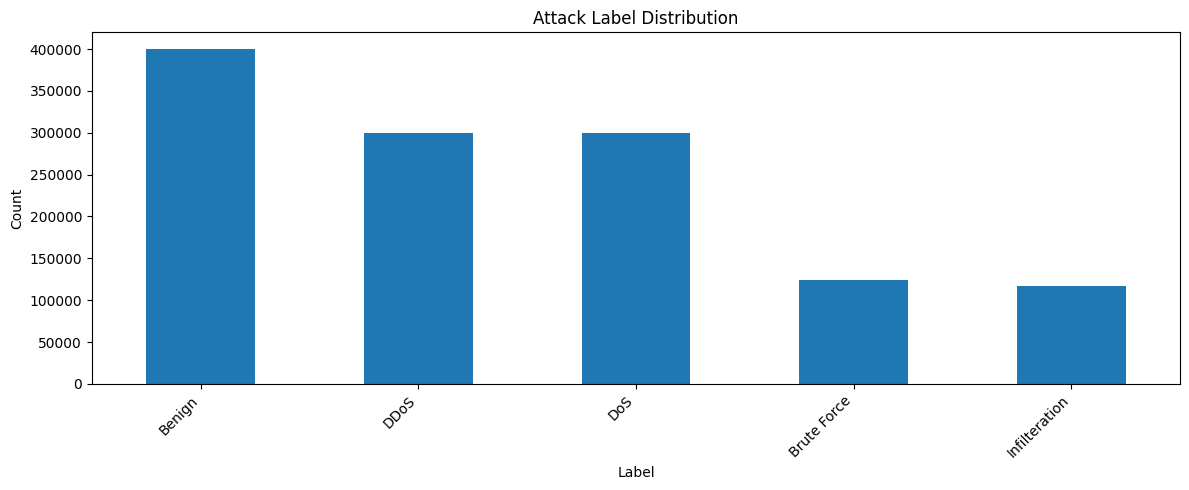

In [15]:
# Label distribution
label_counts = df['Label'].value_counts()

plt.figure(figsize=(12, 5))
label_counts.plot(kind='bar')
plt.title('Attack Label Distribution')
plt.xlabel('Label'); plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()


In [16]:

# ── Group similar attack types ───────────────────────────────────────────────
attack_group_mapping = {
    # # BENIGN
    'Benign': 'BENIGN',
    'DDoS': 'DDoS',
    'DoS': 'DoS',
    'Brute Force': 'Brute Force',
    'Infilteration': 'Infiltration',
}

# Apply mapping; rows with unmapped labels are dropped
df['Label'] = df['Label'].map(attack_group_mapping)
df.dropna(subset=['Label'], inplace=True)

print(f"Groups after mapping : {df['Label'].nunique()}")
for g, cnt in df['Label'].value_counts().items():
    print(f"  {g:<20} {cnt:>10,}  ({cnt/len(df)*100:.2f}%)")


Groups after mapping : 5
  BENIGN                  400,000  (32.25%)
  DDoS                    300,000  (24.19%)
  DoS                     299,999  (24.19%)
  Brute Force             123,982  (10.00%)
  Infiltration            116,361  (9.38%)


In [17]:
# Check missing / infinity values
numeric_cols = df.select_dtypes(include=[np.number]).columns
missing = df.isnull().sum()
inf_counts = {col: np.isinf(df[col]).sum() for col in numeric_cols if np.isinf(df[col]).sum() > 0}
print("Missing:", missing[missing > 0].to_dict() or "None")
print("Infinity:", inf_counts or "None")


Missing: {'Dataset': 1240342}
Infinity: {'SRC_TO_DST_SECOND_BYTES': np.int64(3)}


In [18]:
# Handle inf → NaN → median fill
df_processed = df.copy()
df_processed.replace([np.inf, -np.inf], np.nan, inplace=True)

for col in df_processed.select_dtypes(include=[np.number]).columns:
    if df_processed[col].isnull().sum() > 0:
        df_processed[col].fillna(df_processed[col].median(), inplace=True)

print(f"Shape: {df_processed.shape}  |  NaN remaining: {df_processed.isnull().sum().sum()}")


Shape: (1240342, 43)  |  NaN remaining: 1240342


/tmp/ipykernel_66488/2395811845.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_processed[col].fillna(df_processed[col].median(), inplace=True)
/home/huyho/.local/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/tmp/ipykernel_66488/2395811845.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas

In [19]:
# Drop metadata columns
keywords = ['flow id', 'flow_id', 'source ip', 'destination ip',
            'src ip', 'dst ip', 'timestamp', 'source port', 'dst port']
cols_to_drop = [c for c in df_processed.columns if any(k in c.lower() for k in keywords)]
df_processed.drop(columns=cols_to_drop, inplace=True, errors='ignore')
print(f"Shape: {df_processed.shape}")


Shape: (1240342, 43)


In [20]:
# Encode labels
from sklearn.preprocessing import LabelEncoder
import pickle

le = LabelEncoder()
df_processed['Label_Encoded'] = le.fit_transform(df_processed['Label'])

with open('label_encoder.pkl1', 'wb') as f:
    pickle.dump(le, f)

print(dict(zip(le.classes_, range(len(le.classes_)))))


{'BENIGN': 0, 'Brute Force': 1, 'DDoS': 2, 'DoS': 3, 'Infiltration': 4}


In [21]:
# Train / test split (stratified 80/20)
from sklearn.model_selection import train_test_split

X = df_processed.drop(['Label', 'Label_Encoded'], axis=1)
y = df_processed['Label_Encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")


Train: (992273, 42)  |  Test: (248069, 42)


In [22]:
# RFE — sweep k
from sklearn.feature_selection import RFE, RFECV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

dt_baseline = DecisionTreeClassifier(max_depth=20, min_samples_split=10, min_samples_leaf=4,
                                      random_state=42, class_weight='balanced')
dt_baseline.fit(X_train, y_train)
test_acc = accuracy_score(y_test, dt_baseline.predict(X_test))

base_estimator = DecisionTreeClassifier(max_depth=10, min_samples_split=10, min_samples_leaf=4, random_state=42)
k_values = [k for k in [10, 20, 30, 40, 50, 60, 70] if k < X_train.shape[1]]
rfe_results = {}

for k in k_values:
    rfe = RFE(estimator=base_estimator, n_features_to_select=k, step=140)
    rfe.fit(X_train, y_train)
    rfe_results[k] = {'accuracy': accuracy_score(y_test, rfe.predict(X_test)), 'support': rfe.support_}

best_k = max(rfe_results, key=lambda k: rfe_results[k]['accuracy'])
print(f"Baseline: {test_acc*100:.2f}%  |  Best k={best_k}: {rfe_results[best_k]['accuracy']*100:.2f}%")


Baseline: 89.54%  |  Best k=30: 91.06%


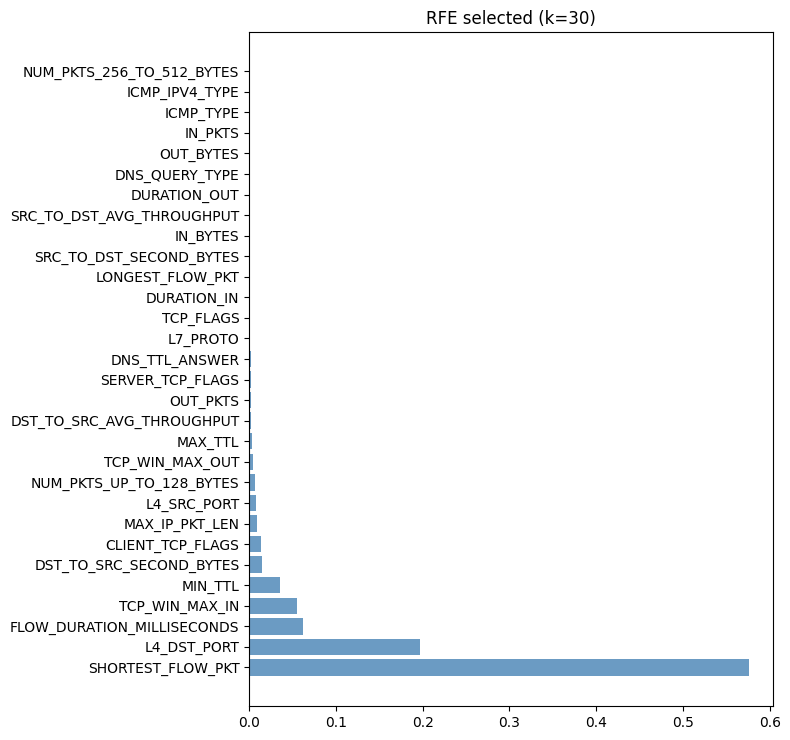

=== RFE k=30 Features (by importance) ===
   1. SHORTEST_FLOW_PKT                             importance=0.5756
   2. L4_DST_PORT                                   importance=0.1965
   3. FLOW_DURATION_MILLISECONDS                    importance=0.0616
   4. TCP_WIN_MAX_IN                                importance=0.0556
   5. MIN_TTL                                       importance=0.0355
   6. DST_TO_SRC_SECOND_BYTES                       importance=0.0146
   7. CLIENT_TCP_FLAGS                              importance=0.0137
   8. MAX_IP_PKT_LEN                                importance=0.0086
   9. L4_SRC_PORT                                   importance=0.0084
  10. NUM_PKTS_UP_TO_128_BYTES                      importance=0.0072
  11. TCP_WIN_MAX_OUT                               importance=0.0040
  12. MAX_TTL                                       importance=0.0033
  13. DST_TO_SRC_AVG_THROUGHPUT                     importance=0.0023
  14. OUT_PKTS                                  

In [23]:

# Feature ranking (RFE best_k)
best_rfe = RFE(estimator=DecisionTreeClassifier(max_depth=10, min_samples_split=10,
               min_samples_leaf=4, random_state=42), n_features_to_select=best_k, step=140)
best_rfe.fit(X_train, y_train)

ranking_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Rank': best_rfe.ranking_,
    'Selected': best_rfe.support_
})
ranking_df['Importance'] = 0.0
ranking_df.loc[ranking_df['Selected'], 'Importance'] = best_rfe.estimator_.feature_importances_

selected_df = (
    ranking_df[ranking_df['Selected']]
    .sort_values('Importance', ascending=True)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(8, max(4, best_k * 0.25)))
ax.barh(selected_df['Feature'], selected_df['Importance'], color='steelblue', alpha=0.8)
ax.set_title(f'RFE selected (k={best_k})'); ax.invert_yaxis()
plt.tight_layout(); plt.show()

# ── Reuse best_rfe for cross-dataset validation (no re-training) ──────────────
import pickle

rfe_features = X_train.columns[best_rfe.support_].tolist()
dt_rfe = DecisionTreeClassifier(max_depth=20, min_samples_split=10, min_samples_leaf=4,
                                 random_state=42, class_weight='balanced')
dt_rfe.fit(X_train[rfe_features], y_train)

rfe_sorted = pd.Series(best_rfe.estimator_.feature_importances_,
                        index=rfe_features).sort_values(ascending=False)

print(f"=== RFE k={best_k} Features (by importance) ===")
for i, (feat, imp) in enumerate(rfe_sorted.items(), 1):
    print(f"  {i:2d}. {feat:<45} importance={imp:.4f}")

with open('dt_rfe20_model.pkl', 'wb') as f: pickle.dump(dt_rfe, f)
with open('rfe20_selected_features.pkl', 'wb') as f: pickle.dump(rfe_features, f)


In [24]:

# ── Classification report ─────────────────────────────────────────────────────
y_test_pred = dt_rfe.predict(X_test[rfe_features])
print(classification_report(y_test, y_test_pred, target_names=le.classes_, digits=4, zero_division=0))


              precision    recall  f1-score   support

      BENIGN     0.9767    0.7066    0.8200     80000
 Brute Force     0.9912    0.9821    0.9866     24797
        DDoS     0.9903    0.9919    0.9911     60000
         DoS     0.9943    0.9969    0.9956     60000
Infiltration     0.4845    0.9447    0.6405     23272

    accuracy                         0.8957    248069
   macro avg     0.8874    0.9244    0.8868    248069
weighted avg     0.9395    0.8957    0.9037    248069



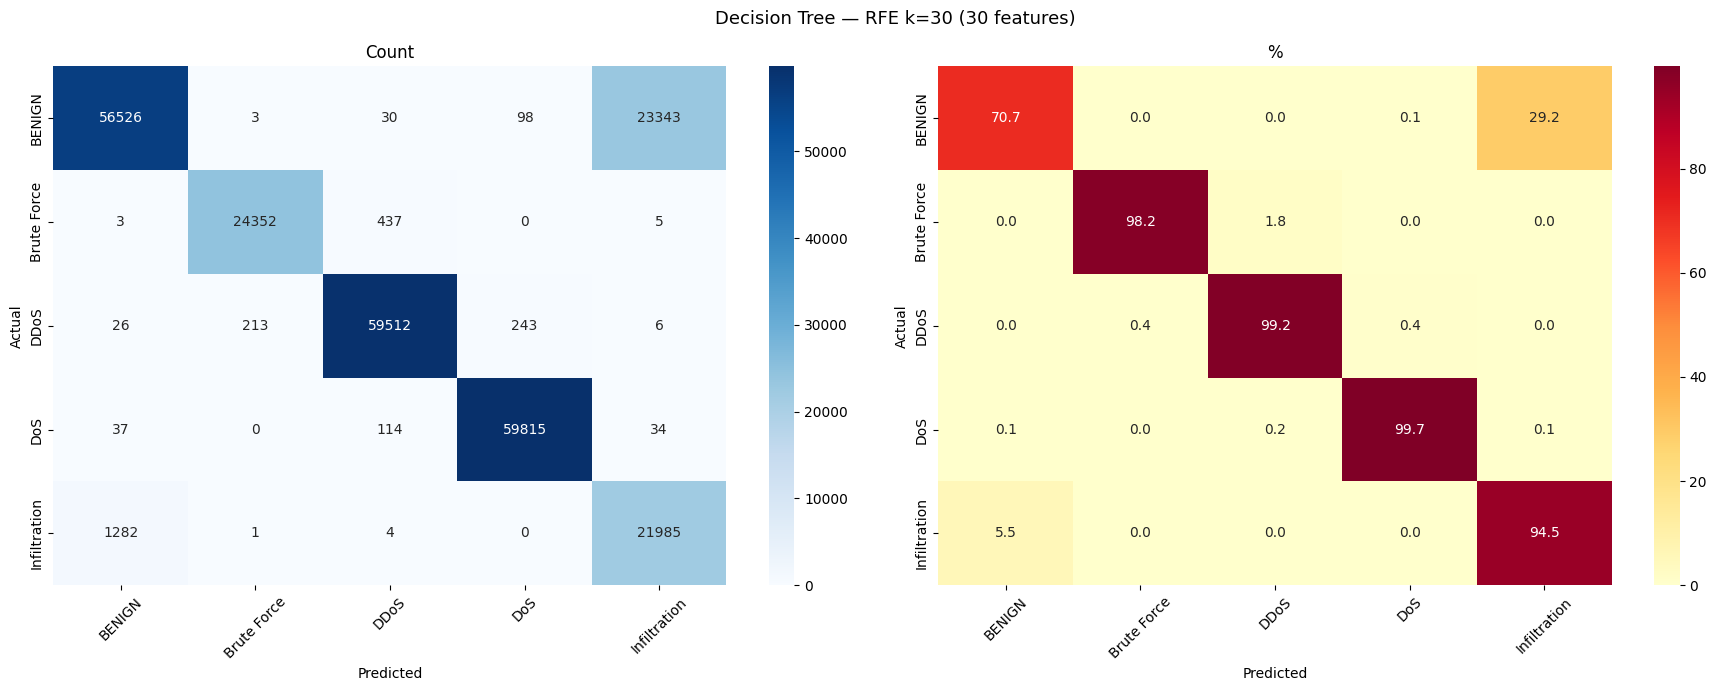

In [25]:

# Confusion matrix — RFE k=20 model
cm = confusion_matrix(y_test, dt_rfe.predict(X_test[rfe_features]))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_, ax=ax1)
ax1.set_title('Count'); ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual'); ax1.tick_params(axis='x', rotation=45)

sns.heatmap(cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100, annot=True, fmt='.1f', cmap='YlOrRd',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax2)
ax2.set_title('%'); ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual'); ax2.tick_params(axis='x', rotation=45)

plt.suptitle(f'Decision Tree — RFE k={best_k} ({best_k} features)', fontsize=13)
plt.tight_layout(); plt.show()
